# Mushroom Classification Project

## Project Link
https://www.kaggle.com/datasets/uciml/mushroom-classification

## Description
This project aims to classify mushrooms as edible or poisonous using tabular data. This is a binary classification problem.

## Data Description
The dataset contains categorical features describing mushroom characteristics such as cap shape, odor, and habitat. The target variable is "class".

## Problem Formulation

This is a binary classification problem where:
- Input: Mushroom features
- Output: Edible (0) or Poisonous (1)

Evaluation Metric:
- Accuracy

In [27]:
import pandas as pd

data = pd.read_csv("mushrooms.csv")

print(data.shape)
data.head()

(8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [21]:
data.info()
data.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   int64
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

### Dataset Overview
- The dataset contains 8124 samples and 23 features.
- All features are categorical variables.
- There are no missing values in the dataset.
- The target variable is "class", where:
  - 0 = edible
  - 1 = poisonous

In [51]:
summary = pd.DataFrame({
    "Feature": data.columns,
    "Type": data.dtypes.values,
    "Unique Values": [data[col].nunique() for col in data.columns],
    "Missing Values": data.isnull().sum().values
})

summary

,Feature,Type,Unique Values,Missing Values
0,class,int64,2,0
1,cap-shape,str,6,0
2,cap-surface,str,4,0
3,cap-color,str,8,0
4,bruises,str,2,0
5,odor,str,7,0
6,gill-attachment,str,2,0
7,gill-spacing,str,2,0
8,gill-size,str,2,0
9,gill-color,str,9,0


### Feature Summary Table

The table above summarizes each feature in the dataset, including its data type, number of unique values, and missing values.

All features are categorical with no missing values after cleaning. The relatively small number of unique values per feature makes the dataset well-suited for classification tasks.

<Axes: title={'center': 'Class Distribution'}, xlabel='class'>

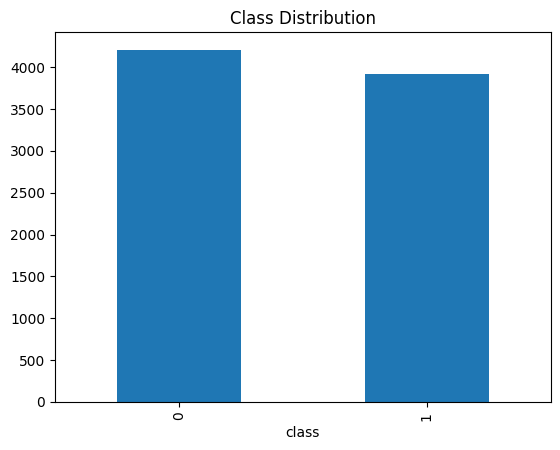

In [22]:
data["class"].value_counts()
data["class"].value_counts().plot(kind="bar", title="Class Distribution")

### Class Distribution
The dataset is relatively balanced between edible and poisonous mushrooms, which is beneficial for training a classification model.

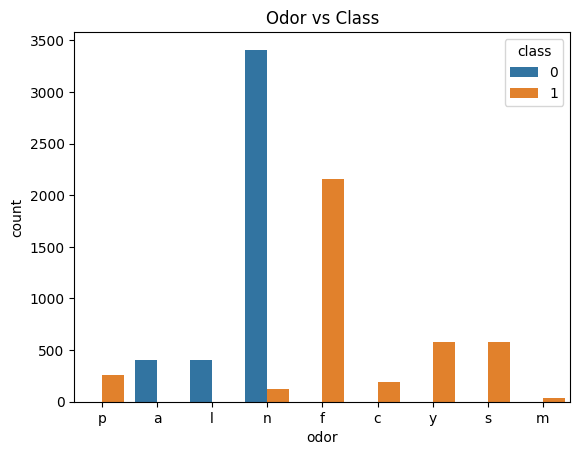

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=data, x="odor", hue="class")
plt.title("Odor vs Class")
plt.show()

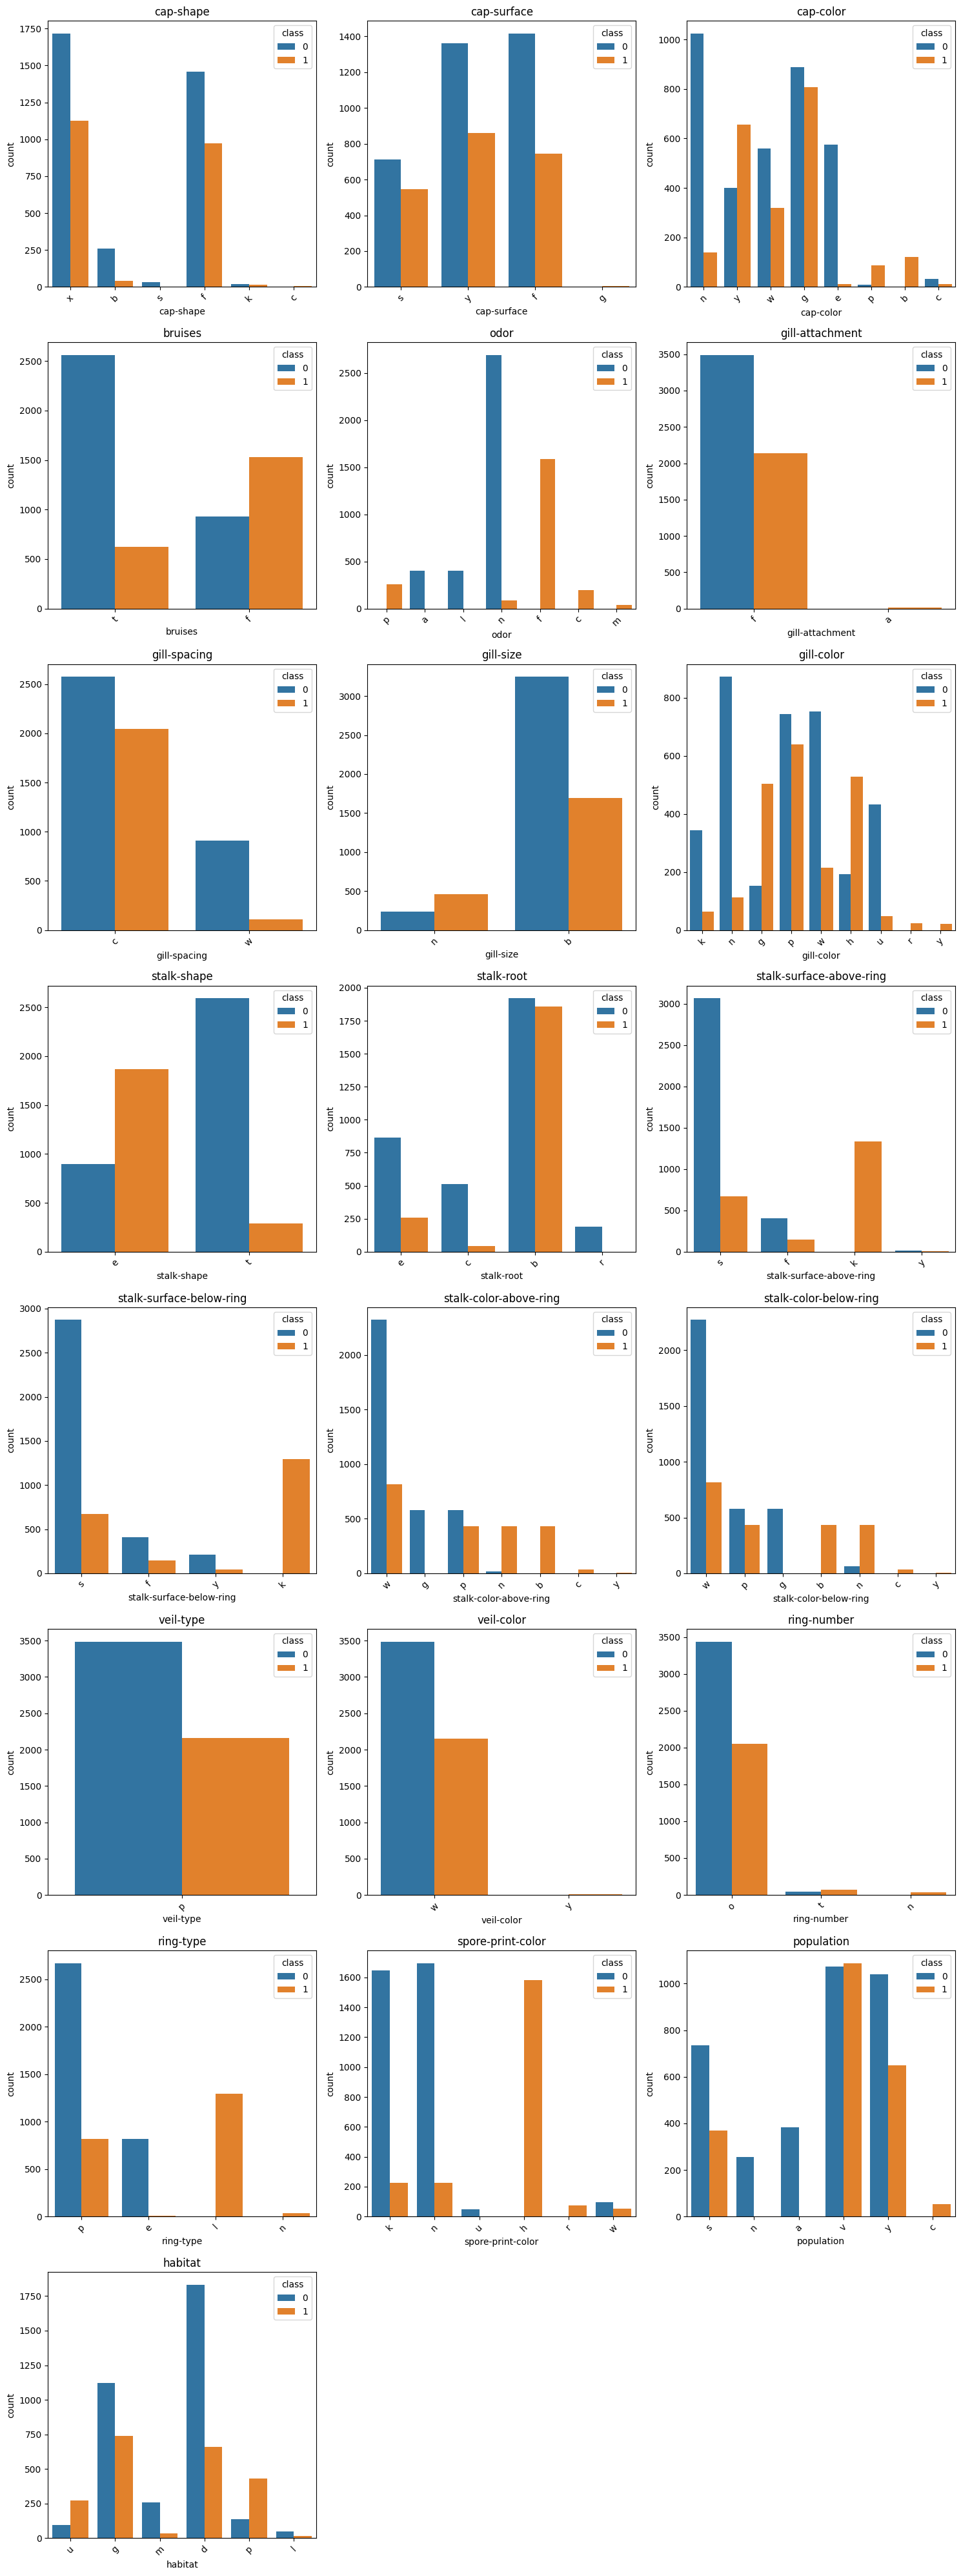

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

features = [col for col in data.columns if col != "class"]

n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 5 * n_rows))

for i, feature in enumerate(features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(data=data, x=feature, hue="class")
    plt.title(feature)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Visualization Insights
Odor is a strong indicator of whether a mushroom is poisonous.

### Feature Comparison

All categorical features were visualized using count plots to compare their distributions across the two classes (edible vs poisonous).

Since the dataset contains only categorical variables, count plots are more appropriate than histograms.

Key observations:
- Several features, especially **odor**, show a clear separation between classes.
- Some feature values appear almost exclusively in one class.
- This explains why machine learning models achieve very high accuracy on this dataset.

Overall, the features provide strong signals for classification.

In [43]:
data = data.replace("?", pd.NA)
data = data.dropna()

### Data Cleaning
Missing values represented by '?' were replaced and removed to ensure clean input for the model.

In [30]:
data["class"] = data["class"].map({"e": 0, "p": 1})

X = data.drop("class", axis=1)
y = data["class"]

X = pd.get_dummies(X)

### Data Preparation
Categorical features were converted into numerical format using one-hot encoding.

## Rescaling
Rescaling was not required since all features are categorical and tree-based models like Random Forest do not depend on feature scaling.

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

### Data Splitting
The dataset was split into training (80%) and validation (20%) sets using stratified sampling to preserve class distribution.

In [33]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Model Selection
Random Forest was chosen due to its effectiveness with categorical data and ability to capture complex relationships.

In [48]:
from sklearn.metrics import accuracy_score

preds = model.predict(X_val)
accuracy = accuracy_score(y_val, preds)

print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 1.0000


In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_val)
lr_acc = accuracy_score(y_val, lr_preds)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 1.0


In [40]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_val)
dt_acc = accuracy_score(y_val, dt_preds)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 1.0


In [41]:
rf_preds = model.predict(X_val)
rf_acc = accuracy_score(y_val, rf_preds)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 1.0


In [42]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [lr_acc, dt_acc, rf_acc]
})

results

,Model,Accuracy
0,Logistic Regression,1.0
1,Decision Tree,1.0
2,Random Forest,1.0


### Model Performance
The model achieved very high accuracy, indicating strong predictive performance.
The near-perfect accuracy is due to the dataset being highly separable, particularly because features like odor strongly determine the target.

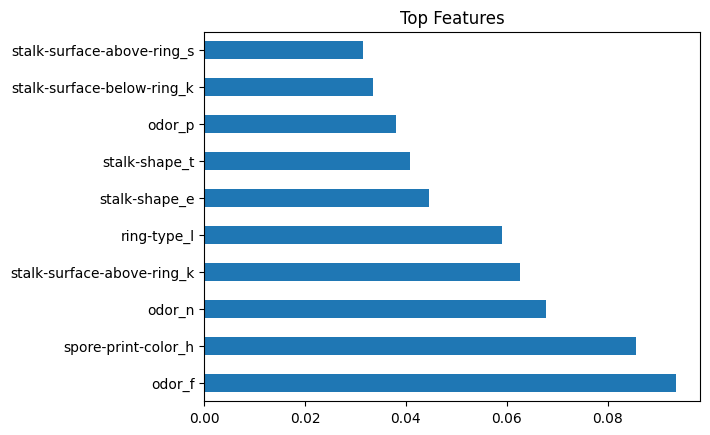

In [35]:
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind="barh")
plt.title("Top Features")
plt.show()

### Feature Importance
Odor is the most important feature, followed by other physical attributes.

<Axes: >

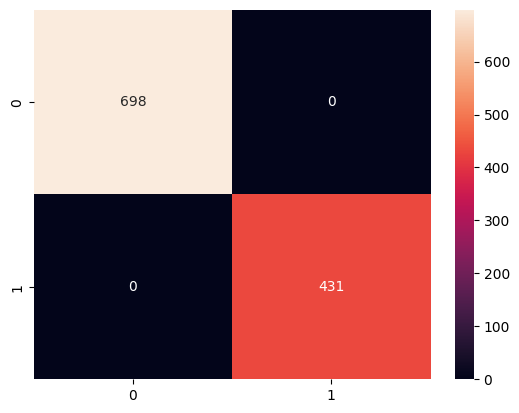

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_val, preds)
sns.heatmap(cm, annot=True, fmt="d")

### Confusion Matrix

The confusion matrix provides a detailed breakdown of the model's predictions compared to the actual values.

It shows:
- True Positives (correctly predicted poisonous mushrooms)
- True Negatives (correctly predicted edible mushrooms)
- False Positives (edible mushrooms incorrectly predicted as poisonous)
- False Negatives (poisonous mushrooms incorrectly predicted as edible)

This helps evaluate not only overall accuracy but also the types of errors made by the model.

In [46]:
from sklearn.metrics import roc_auc_score

probs = model.predict_proba(X_val)[:,1]
roc_auc = roc_auc_score(y_val, probs)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 1.0


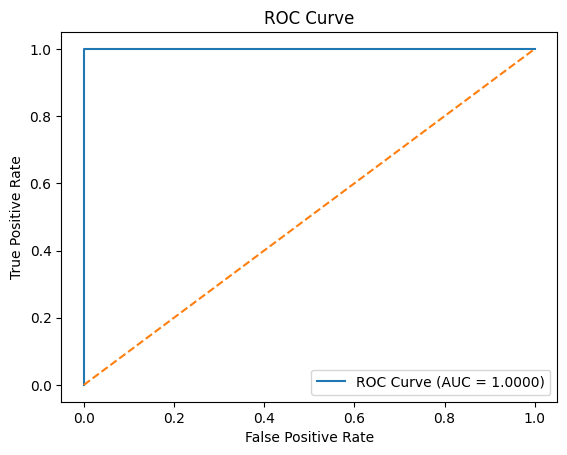

In [47]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities
probs = model.predict_proba(X_val)[:,1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_val, probs)

# Compute AUC
roc_auc = roc_auc_score(y_val, probs)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--')  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### ROC-AUC Score

The ROC-AUC score measures the model's ability to distinguish between classes.

Unlike accuracy, it evaluates how well the model ranks predictions across different thresholds.

The high ROC-AUC score indicates that the model can effectively separate edible and poisonous mushrooms.

### ROC Curve

The ROC curve illustrates the model’s ability to distinguish between edible and poisonous mushrooms at different classification thresholds.

- The x-axis represents the False Positive Rate.
- The y-axis represents the True Positive Rate.
- The diagonal line represents a random classifier.

The curve being close to the top-left corner indicates strong model performance. The high AUC value confirms that the model effectively separates the two classes.

### Evaluation Note

Since this is not a Kaggle competition dataset, there is no leaderboard score.  
Model performance was evaluated using validation accuracy and ROC-AUC instead.

### Model Application

The dataset does not include a separate test set.  
Instead, the trained model was applied to the validation dataset to simulate unseen data evaluation.

### Note on Model Performance

All models achieved near-perfect accuracy on the validation dataset.  
This is due to the dataset being highly separable, with certain features (such as odor) strongly determining whether a mushroom is poisonous or edible.

While this indicates excellent performance, it also suggests that the problem is relatively easy for machine learning models and may not reflect performance on more complex real-world datasets.

## Conclusion

This project successfully classified mushrooms with very high accuracy. 
The dataset is highly separable, with features such as odor being strong predictors.
The combination of high accuracy, ROC-AUC, and confusion matrix confirms that the model performs reliably across different evaluation metrics.